# Initial Population vs Optimized Pareto Front

Same idea as Fig. 3 in Lou (2023), extended to our three objectives:
- **Annualized return** ( = w · mean × 252 )
- **Annualized volatility** ( = sqrt(variance × 252) )
- **Diversification ratio** ( = (w · σ) / σ_p )

We render 3 pairwise 2D projections (the standard way to show a 3-objective Pareto front) plus a 3D view.

In [1]:
import math
import random
import copy
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3D projection)

from portfolio.data import load_from_pipeline
from portfolio.problem import PortfolioProblem
from portfolio.optimizer import PortfolioEvolution

TRADING_DAYS = 252
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [2]:
mean_returns, cov_matrix, std_returns, ticker_names = load_from_pipeline()
problem = PortfolioProblem(mean_returns, cov_matrix, std_returns)
print(f"num assets: {problem.num_assets}")

Loaded 464 stocks, 2513 trading days
num assets: 464


In [3]:
# Tweak these if it runs too slow on your machine.
POPULATION = 100
GENERATIONS = 100
INIT_SAMPLE_SIZE = 1000  # how many random portfolios to plot as the "before" cloud

## 1. Sample the random initial population ("before")
Same generator the optimizer uses (`problem.generate_individual` + `calculate_objectives`).

In [4]:
def metrics_from_individual(ind):
    """Return (ann_return_pct, ann_vol_pct, div_ratio) for an evaluated individual."""
    w = np.asarray(ind.features, dtype=np.float64)
    port_return_pct = float(w @ problem.mean_returns_np) * TRADING_DAYS * 100
    ann_vol_pct = math.sqrt(max(ind.objectives[1], 0.0) * TRADING_DAYS) * 100
    div_ratio = -ind.objectives[2]
    return port_return_pct, ann_vol_pct, div_ratio

init_metrics = []
for _ in range(INIT_SAMPLE_SIZE):
    ind = problem.generate_individual()
    problem.calculate_objectives(ind)
    init_metrics.append(metrics_from_individual(ind))

init_metrics = np.array(init_metrics)
print(f"sampled {len(init_metrics)} random portfolios")
print(f"  return %  range: {init_metrics[:,0].min():.2f} .. {init_metrics[:,0].max():.2f}")
print(f"  vol %     range: {init_metrics[:,1].min():.2f} .. {init_metrics[:,1].max():.2f}")
print(f"  div ratio range: {init_metrics[:,2].min():.3f} .. {init_metrics[:,2].max():.3f}")

sampled 1000 random portfolios
  return %  range: 11.22 .. 12.70
  vol %     range: 18.09 .. 19.05
  div ratio range: 1.685 .. 1.752


## 2. Run NSGA-II and collect the final Pareto front ("after")

In [5]:
evolution = PortfolioEvolution(
    problem,
    num_of_generations=GENERATIONS,
    num_of_individuals=POPULATION,
    use_lou_selection=True,
    use_lou_mutation=True,
    use_lou_init=True,
)
pareto_front = evolution.evolve()
final_pop = evolution.population.population

front_metrics = np.array([metrics_from_individual(ind) for ind in pareto_front])
final_pop_metrics = np.array([metrics_from_individual(ind) for ind in final_pop])
print(f"Pareto front size: {len(pareto_front)} | final pop size: {len(final_pop)}")

NSGA-II: 100%|██████████| 100/100 [00:05<00:00, 18.58it/s]

Pareto front size: 20 | final pop size: 100


## 3. Pairwise 2D projections (cleanest view for 3-objective fronts)
Each panel is one of the three 2D slices, with the random initial cloud (blue) and the final Pareto front (red) overlaid so you can see the movement directly.

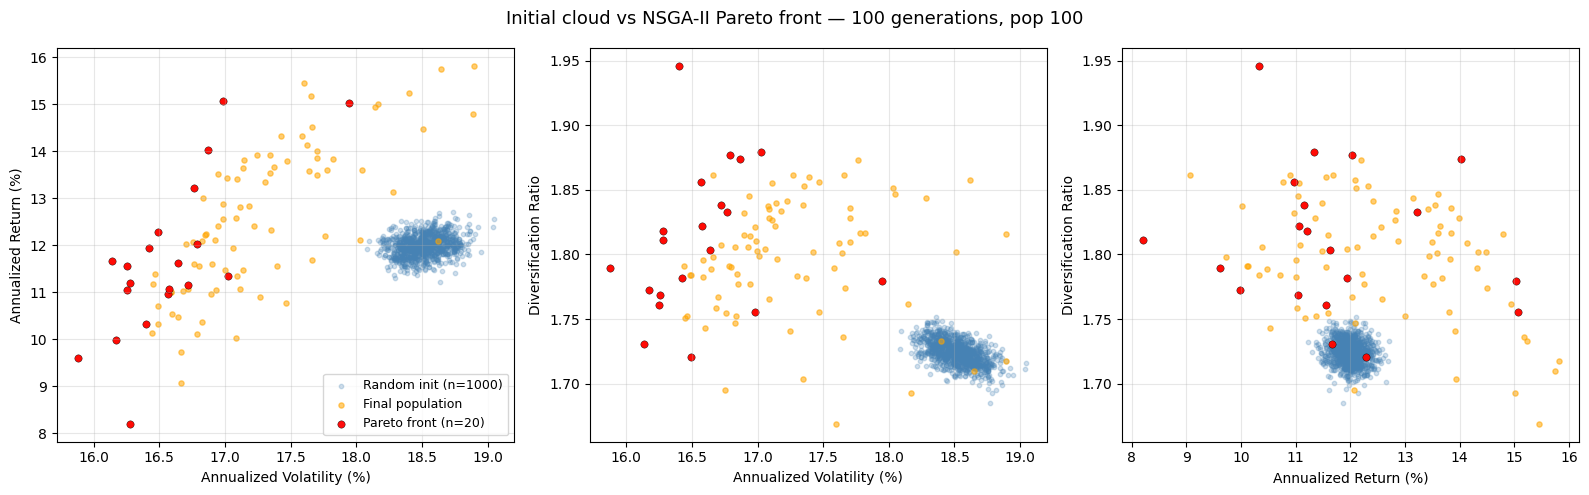

In [6]:
# Column indices: 0 = return %, 1 = vol %, 2 = div ratio
labels = {0: "Annualized Return (%)", 1: "Annualized Volatility (%)", 2: "Diversification Ratio"}
pairs = [(1, 0), (1, 2), (0, 2)]  # (vol, ret), (vol, div), (ret, div)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (xi, yi) in zip(axes, pairs):
    ax.scatter(
        init_metrics[:, xi], init_metrics[:, yi],
        s=10, c="steelblue", alpha=0.25, label=f"Random init (n={len(init_metrics)})",
    )
    ax.scatter(
        final_pop_metrics[:, xi], final_pop_metrics[:, yi],
        s=14, c="orange", alpha=0.55, label="Final population",
    )
    ax.scatter(
        front_metrics[:, xi], front_metrics[:, yi],
        s=28, c="red", edgecolor="black", linewidth=0.3,
        alpha=0.95, label=f"Pareto front (n={len(front_metrics)})",
    )
    ax.set_xlabel(labels[xi])
    ax.set_ylabel(labels[yi])
    ax.grid(True, alpha=0.3)

axes[0].legend(loc="best", fontsize=9)
fig.suptitle(
    f"Initial cloud vs NSGA-II Pareto front — {GENERATIONS} generations, pop {POPULATION}",
    fontsize=13,
)
fig.tight_layout()
plt.show()

## 4. 3D view — single axes, both clouds overlaid
Use the interactive rotation in the notebook to see the front structure; the 2D projections above are the readable summary.

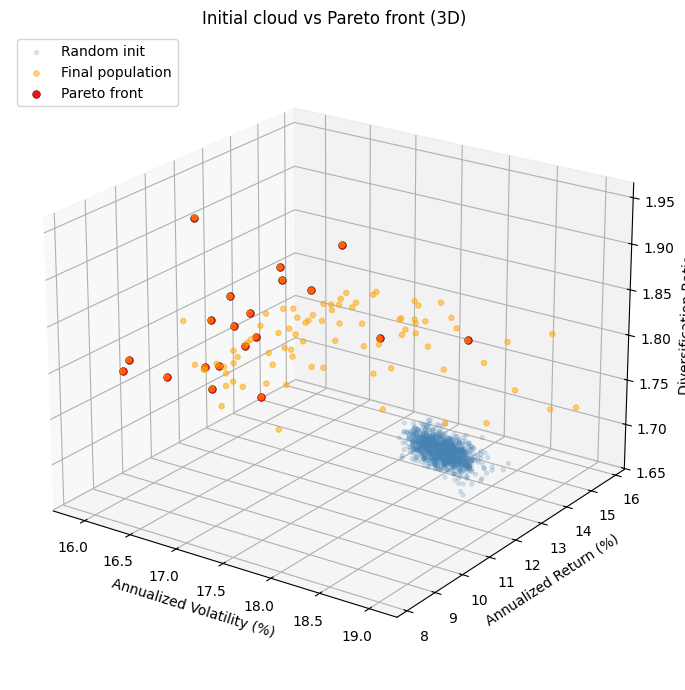

In [7]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(projection="3d")

ax.scatter(
    init_metrics[:, 1], init_metrics[:, 0], init_metrics[:, 2],
    s=8, c="steelblue", alpha=0.18, depthshade=True, label="Random init",
)
ax.scatter(
    final_pop_metrics[:, 1], final_pop_metrics[:, 0], final_pop_metrics[:, 2],
    s=14, c="orange", alpha=0.5, depthshade=True, label="Final population",
)
ax.scatter(
    front_metrics[:, 1], front_metrics[:, 0], front_metrics[:, 2],
    s=32, c="red", edgecolor="black", linewidth=0.3,
    alpha=0.95, depthshade=False, label="Pareto front",
)

ax.set_xlabel("Annualized Volatility (%)")
ax.set_ylabel("Annualized Return (%)")
ax.set_zlabel("Diversification Ratio")
ax.view_init(elev=22, azim=-55)
ax.set_title("Initial cloud vs Pareto front (3D)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()